In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("RiskLens.csv")
df.head(1000)

,Date,Customer_ID,Gender,Age,Region,Acquisition_Channel,Lead_Source,Device_Type,Product_Plan,Subscription_Type,...,Customer_Satisfaction_Score,Employees_Count,year,month,quarter,Total_Cost,Profit,Profit_Margin_%,Effective_Revenue,Is_fraud
0,01-01-2023,CUST108549,Male,45,Uae,Email,App,Tablet,Basic,Monthly,...,4.8,162,2023,1,1,7898.27,7596.76,49.027075,15495.03,1.0
1,01-01-2023,CUST100742,Female,40,India,Email,App,Web,Standard,Monthly,...,4.8,246,2023,1,1,4220.42,3348.70,44.241603,7569.12,0.0
2,01-01-2023,CUST102330,Male,31,Usa,Organic,App,Mobile,Basic,Monthly,...,3.9,107,2023,1,1,5175.45,1874.10,26.584676,7049.55,0.0
3,01-01-2023,CUST100558,Female,36,Canada,Referral,App,Tablet,Premium,Monthly,...,4.6,81,2023,1,1,6384.54,5618.89,46.810703,12003.43,1.0
4,01-01-2023,CUST107249,Male,35,India,Social Media,Partner,Tablet,Standard,Monthly,...,3.9,189,2023,1,1,8813.50,-3443.32,-64.119266,5370.18,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,26-04-2023,CUST104488,Female,57,Uk,Social Media,Website,Tablet,Basic,Monthly,...,3.7,184,2023,4,2,2241.68,6515.05,74.400490,8756.73,0.0
996,26-04-2023,CUST104912,Female,57,Canada,Social Media,App,Mobile,Standard,Monthly,...,2.5,213,2023,4,2,9078.97,-8085.49,-813.855337,993.48,0.0
997,26-04-2023,CUST101367,Male,28,India,Email,Website,Web,Basic,Monthly,...,5.0,263,2023,4,2,8071.44,899.03,10.022106,8970.47,0.0
998,26-04-2023,CUST101715,Male,56,Uae,Referral,App,Mobile,Basic,Monthly,...,4.7,185,2023,4,2,9953.97,3504.11,26.037221,13458.08,0.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5332 entries, 0 to 5331
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Date                         5332 non-null   object 
 1   Customer_ID                  5332 non-null   object 
 2   Gender                       5332 non-null   object 
 3   Age                          5332 non-null   int64  
 4   Region                       5332 non-null   object 
 5   Acquisition_Channel          5332 non-null   object 
 6   Lead_Source                  5332 non-null   object 
 7   Device_Type                  5332 non-null   object 
 8   Product_Plan                 5332 non-null   object 
 9   Subscription_Type            5332 non-null   object 
 10  Monthly_Revenue              5332 non-null   float64
 11  Discount_Amount              5332 non-null   float64
 12  Net_Revenue                  5332 non-null   float64
 13  Marketing_Cost    

In [4]:
df.shape

(5332, 30)

In [5]:
df.columns

Index(['Date', 'Customer_ID', 'Gender', 'Age', 'Region', 'Acquisition_Channel',
       'Lead_Source', 'Device_Type', 'Product_Plan', 'Subscription_Type',
       'Monthly_Revenue', 'Discount_Amount', 'Net_Revenue', 'Marketing_Cost',
       'Sales_Cost', 'Support_Cost', 'Payment_Mode', 'Is_Renewed',
       'Is_Churned', 'Customer_Lifetime_Months', 'Customer_Satisfaction_Score',
       'Employees_Count', 'year', 'month', 'quarter', 'Total_Cost', 'Profit',
       'Profit_Margin_%', 'Effective_Revenue', 'Is_fraud'],
      dtype='object')

In [6]:
df.isnull().sum()

Date                           0
Customer_ID                    0
Gender                         0
Age                            0
Region                         0
Acquisition_Channel            0
Lead_Source                    0
Device_Type                    0
Product_Plan                   0
Subscription_Type              0
Monthly_Revenue                0
Discount_Amount                0
Net_Revenue                    0
Marketing_Cost                 0
Sales_Cost                     0
Support_Cost                   0
Payment_Mode                   0
Is_Renewed                     0
Is_Churned                     0
Customer_Lifetime_Months       0
Customer_Satisfaction_Score    0
Employees_Count                0
year                           0
month                          0
quarter                        0
Total_Cost                     0
Profit                         0
Profit_Margin_%                1
Effective_Revenue              1
Is_fraud                       1
dtype: int

In [7]:
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

In [8]:
df["Date"]=pd.to_datetime(df["Date"])

In [9]:
df.duplicated().sum()

0

In [10]:
print(df['Date'].dtype)
print(df['Date'].head())

datetime64[ns]
0   2023-01-01
1   2023-01-01
2   2023-01-01
3   2023-01-01
4   2023-01-01
Name: Date, dtype: datetime64[ns]


In [11]:
df['date'] = pd.to_datetime(df['Date'], errors='coerce')

In [12]:
print(df['date'].isnull().sum()) 

0


In [13]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter

print(df[['date', 'year', 'month', 'quarter']].head())

        date  year  month  quarter
0 2023-01-01  2023      1        1
1 2023-01-01  2023      1        1
2 2023-01-01  2023      1        1
3 2023-01-01  2023      1        1
4 2023-01-01  2023      1        1


In [14]:
#For numeric columns — fill with median
numeric_cols = ['Monthly_Revenue', 'Discount_Amount', 'Net_Revenue',
                'Marketing_Cost', 'Sales_Cost', 'Support_Cost',
                'Customer_Satisfaction_Score', 'Customer_Lifetime_Months']

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [15]:
#For categorical columns — fill with mode
cat_cols = ['Gender', 'Region', 'Acquisition_Channel',
            'Lead_Source', 'Device_Type', 'Product_Plan',
            'Subscription_Type', 'Payment_Mode']

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [16]:
df=df.dropna()

In [17]:
df.drop_duplicates(inplace=True)
print("After cleaning:", df.shape)

After cleaning: (5331, 31)


In [18]:
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)
    return df

for col in ['Monthly_Revenue', 'Net_Revenue', 'Marketing_Cost']:
    df = remove_outliers(df, col)

In [19]:
# Total cost
df['Total_Cost'] = df['Marketing_Cost'] + df['Sales_Cost'] + df['Support_Cost']

# Profit
df['Profit'] = df['Net_Revenue'] - df['Total_Cost']

# Profit margin %
df['Profit_Margin_%'] = (df['Profit'] / df['Net_Revenue']) * 100

# Revenue after discount
df['Effective_Revenue'] = df['Monthly_Revenue'] - df['Discount_Amount']

In [20]:
for col in cat_cols:
    df[col] = df[col].str.strip().str.title()

# Fix boolean-like columns
df['Is_Renewed'] = df['Is_Renewed'].map({1: 'Yes', 0: 'No', 'Yes': 'Yes', 'No': 'No'})
df['Is_Churned'] = df['Is_Churned'].map({1: 'Yes', 0: 'No', 'Yes': 'Yes', 'No': 'No'})

In [21]:
total_revenue = df["Net_Revenue"].sum()
print("Total Revenue:",total_revenue)

Total Revenue: 46387501.18


In [22]:
total_profit = df["Profit"].sum()
print("Total Profit:",total_profit)

Total Profit: 13370904.8


In [23]:
Region_revenue = df.groupby("Region")["Net_Revenue"].sum().sort_values(ascending=False)
print(Region_revenue)

Region
Canada    9692434.83
Uae       9448602.89
Uk        9151791.01
Usa       9075796.76
India     9018875.69
Name: Net_Revenue, dtype: float64


In [24]:
# Better styling
plt.style.use('seaborn-v0_8')
sns.set_palette("Set2")

In [25]:
print(df.columns.tolist())

['Date', 'Customer_ID', 'Gender', 'Age', 'Region', 'Acquisition_Channel', 'Lead_Source', 'Device_Type', 'Product_Plan', 'Subscription_Type', 'Monthly_Revenue', 'Discount_Amount', 'Net_Revenue', 'Marketing_Cost', 'Sales_Cost', 'Support_Cost', 'Payment_Mode', 'Is_Renewed', 'Is_Churned', 'Customer_Lifetime_Months', 'Customer_Satisfaction_Score', 'Employees_Count', 'year', 'month', 'quarter', 'Total_Cost', 'Profit', 'Profit_Margin_%', 'Effective_Revenue', 'Is_fraud', 'date']


Index(['Date', 'Customer_ID', 'Gender', 'Age', 'Region', 'Acquisition_Channel',
       'Lead_Source', 'Device_Type', 'Product_Plan', 'Subscription_Type',
       'Monthly_Revenue', 'Discount_Amount', 'Net_Revenue', 'Marketing_Cost',
       'Sales_Cost', 'Support_Cost', 'Payment_Mode', 'Is_Renewed',
       'Is_Churned', 'Customer_Lifetime_Months', 'Customer_Satisfaction_Score',
       'Employees_Count', 'year', 'month', 'quarter', 'Total_Cost', 'Profit',
       'Profit_Margin_%', 'Effective_Revenue', 'Is_fraud'],
      dtype='object')
   year  month  Net_Revenue
0  2023      1   2375469.28
1  2023      2   2062410.72
2  2023      3   2274083.70
3  2023      4   2166925.99
4  2023      5   2626006.24


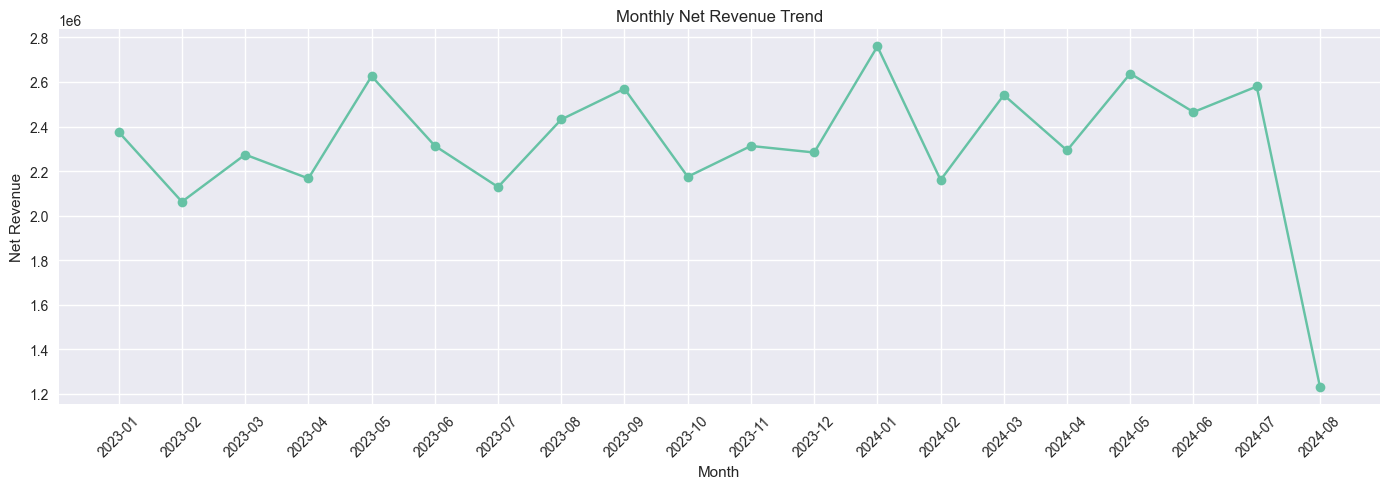

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("RiskLens.csv")

# CHECK columns first
print(df.columns)

# Create Monthly Revenue table
Monthly_Revenue = (
    df.groupby(['year','month'])['Net_Revenue']
    .sum()
    .reset_index()
)

print(Monthly_Revenue.head())

# Create period
Monthly_Revenue['period'] = (
    Monthly_Revenue['year'].astype(str) + '-' +
    Monthly_Revenue['month'].astype(str).str.zfill(2)
)

# Plot
plt.figure(figsize=(14,5))
plt.plot(Monthly_Revenue['period'],
         Monthly_Revenue['Net_Revenue'],
         marker='o')

plt.xticks(rotation=45)
plt.title("Monthly Net Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Net Revenue")

plt.tight_layout()
plt.show()


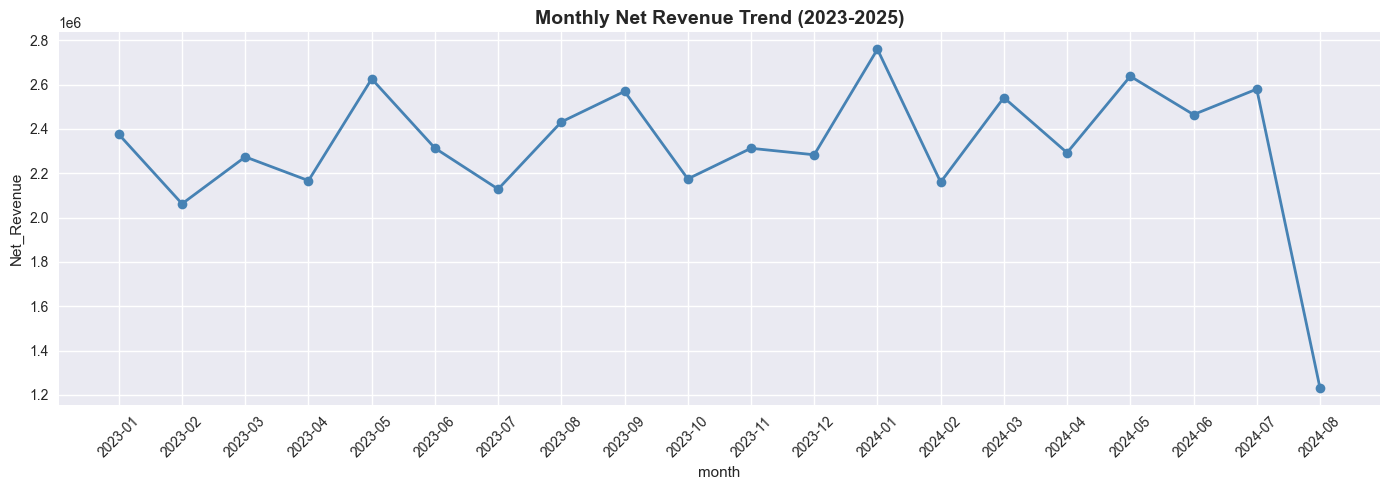

In [28]:
#Graph 1 — Monthly Revenue Trend (Line Chart)
import matplotlib.pyplot as plt
import seaborn as sns
Monthly_Revenue = df.groupby(['year', 'month'])['Net_Revenue'].sum().reset_index()
Monthly_Revenue['period'] = Monthly_Revenue['year'].astype(str) + '-' + Monthly_Revenue['month'].astype(str).str.zfill(2)

plt.figure(figsize=(14, 5))
plt.plot(Monthly_Revenue['period'], Monthly_Revenue['Net_Revenue'], marker='o', color='steelblue', linewidth=2)
plt.title('Monthly Net Revenue Trend (2023-2025)', fontsize=14, fontweight='bold')

plt.xlabel('month')
plt.ylabel('Net_Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('graph1_revenue_trend.png', dpi=150)
plt.show()


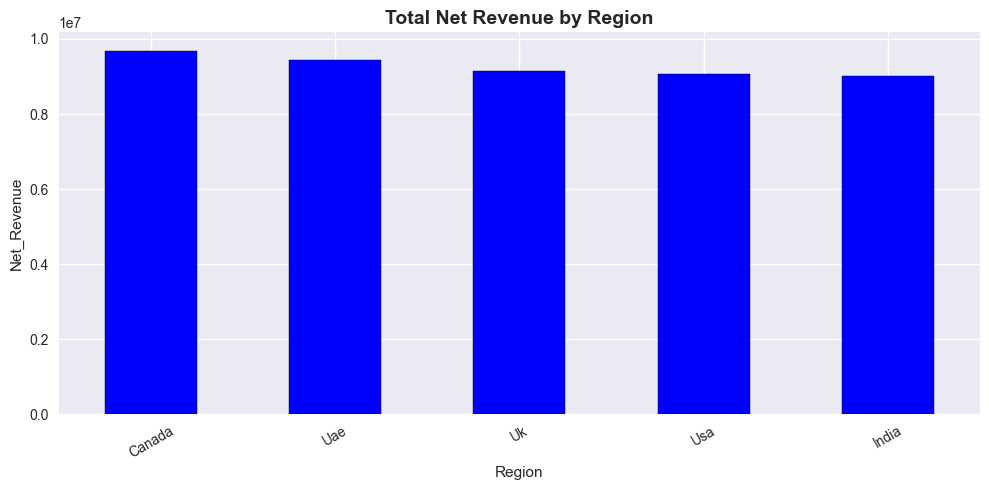

In [29]:
#Graph 2 — Revenue by Region (Bar Chart)
import matplotlib.pyplot as plt
import seaborn as sns
Region_rev = df.groupby('Region')['Net_Revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
Region_rev.plot(kind='bar', color='Blue', edgecolor='black')
plt.title('Total Net Revenue by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Net_Revenue')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('graph2_revenue_by_region.png', dpi=150)
plt.show()

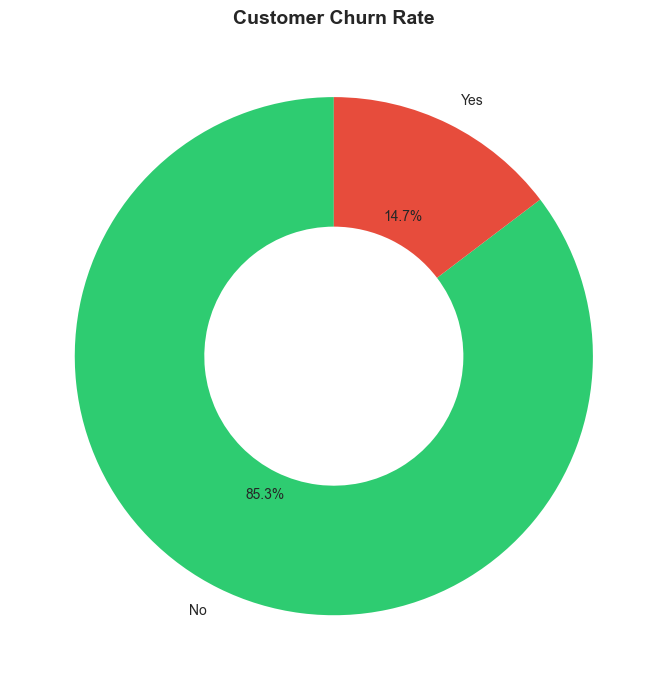

In [30]:
#Graph 3 — Churn Rate (Pie / Donut Chart)
import matplotlib.pyplot as plt
import seaborn as sns
churn_counts = df['Is_Churned'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
        startangle=90, wedgeprops=dict(width=0.5),
        colors=['#2ecc71', '#e74c3c'])
plt.title('Customer Churn Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('graph3_churn_rate.png', dpi=150)
plt.show()

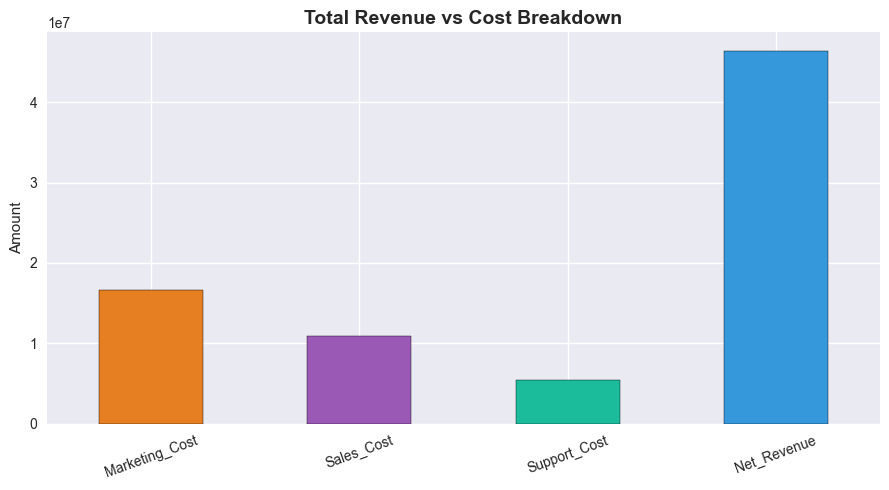

In [31]:
#Graph 4 — Revenue vs Cost Comparison (Grouped Bar)
cost_data = df[['Marketing_Cost', 'Sales_Cost', 'Support_Cost', 'Net_Revenue']].sum()

plt.figure(figsize=(9, 5))
cost_data.plot(kind='bar', color=['#e67e22','#9b59b6','#1abc9c','#3498db'], edgecolor='black')
plt.title('Total Revenue vs Cost Breakdown', fontsize=14, fontweight='bold')
plt.ylabel('Amount')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('graph4_revenue_vs_cost.png', dpi=150)
plt.show()


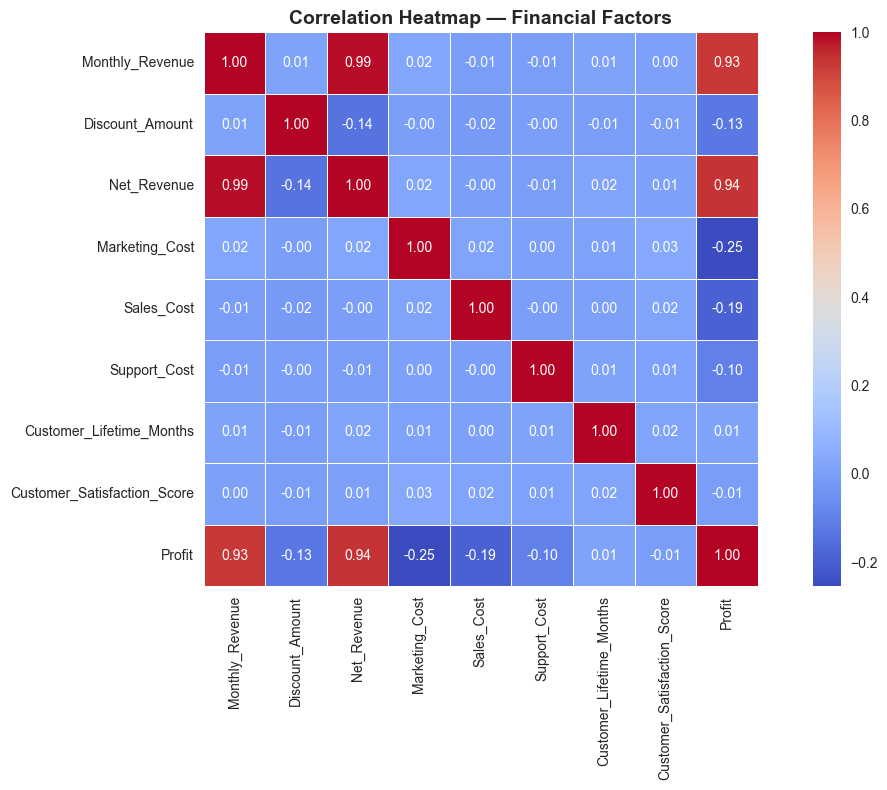

In [32]:
#Graph 5 — Correlation Heatmap
plt.figure(figsize=(12, 8))
numeric_df = df[['Monthly_Revenue', 'Discount_Amount', 'Net_Revenue',
                  'Marketing_Cost', 'Sales_Cost', 'Support_Cost',
                  'Customer_Lifetime_Months', 'Customer_Satisfaction_Score', 'Profit']]

sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap — Financial Factors', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('graph5_heatmap.png', dpi=150)
plt.show()

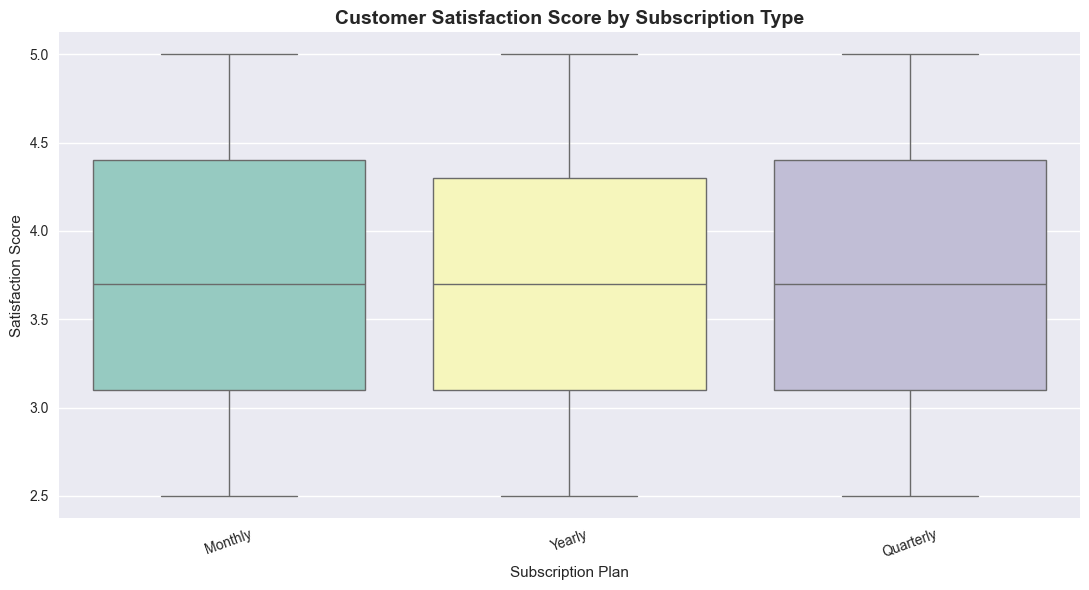

In [33]:
#Graph 6 — Customer Satisfaction by Subscription Plan (Box Plot)
plt.figure(figsize=(11, 6))
sns.boxplot(data=df, x='Subscription_Type', y='Customer_Satisfaction_Score',
            palette='Set3')
plt.title('Customer Satisfaction Score by Subscription Type', fontsize=14, fontweight='bold')
plt.xlabel('Subscription Plan')
plt.ylabel('Satisfaction Score')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('graph6_satisfaction_boxplot.png', dpi=150)
plt.show()

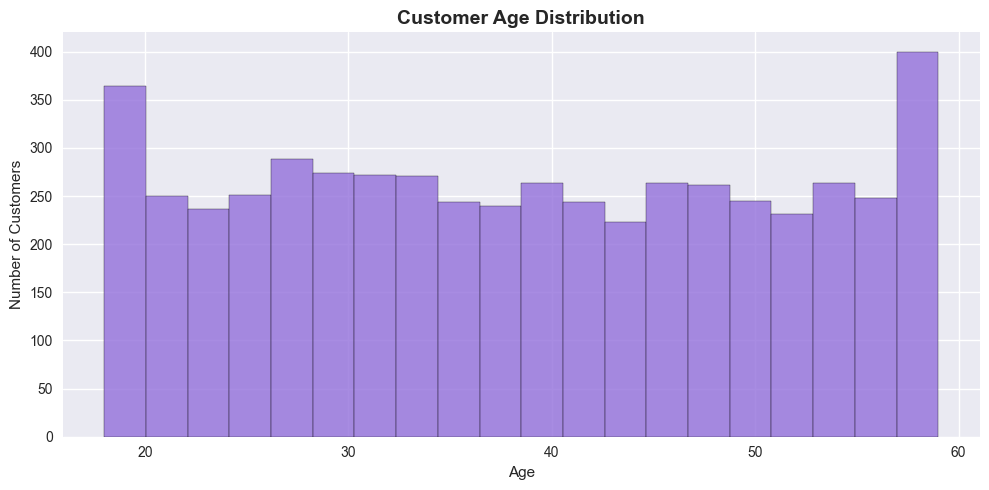

In [34]:
#Graph 7 — Age Distribution (Histogram)
plt.figure(figsize=(10, 5))
plt.hist(df['Age'], bins=20, color='mediumpurple', edgecolor='black', alpha=0.8)
plt.title('Customer Age Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('graph7_age_distribution.png', dpi=150)
plt.show()


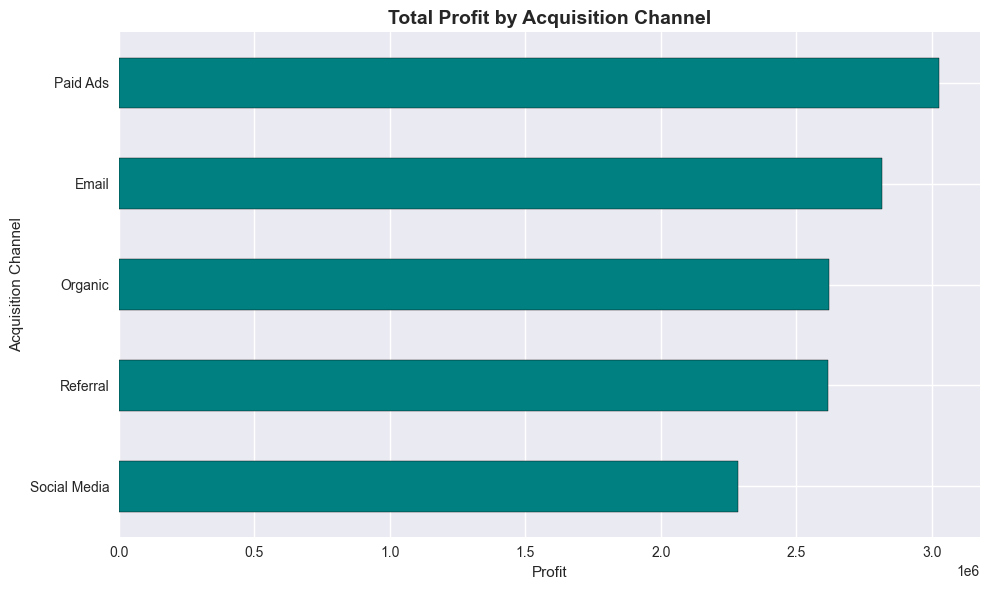

In [35]:
#Graph 8 — Profit by Acquisition Channel (Horizontal Bar)
channel_profit = df.groupby('Acquisition_Channel')['Profit'].sum().sort_values()

plt.figure(figsize=(10, 6))
channel_profit.plot(kind='barh', color='teal', edgecolor='black')
plt.title('Total Profit by Acquisition Channel', fontsize=14, fontweight='bold')
plt.xlabel('Profit')
plt.ylabel('Acquisition Channel')
plt.tight_layout()
plt.savefig('graph8_profit_by_channel.png', dpi=150)
plt.show()

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("RiskLens.csv")

In [37]:
region_revenue = (
    df.groupby('Region')['Net_Revenue']
    .sum()
    .sort_values(ascending=False)
)

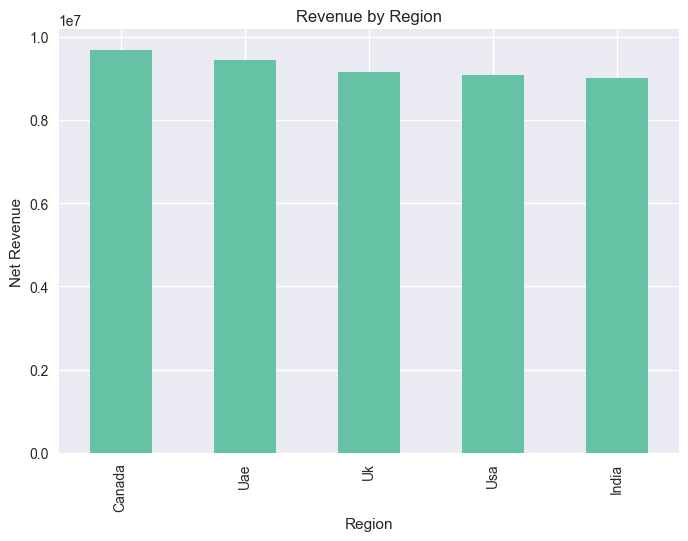

In [38]:
region_revenue.plot(kind="bar")

plt.title("Revenue by Region")
plt.ylabel("Net Revenue")
plt.xlabel("Region")

plt.show()

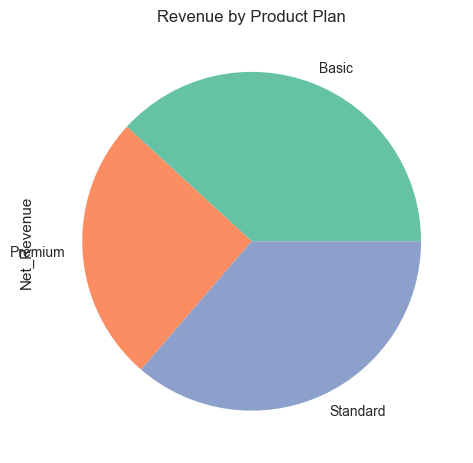

In [39]:
plan_revenue = df.groupby("Product_Plan")["Net_Revenue"].sum()
plan_revenue.plot(kind="pie")
plt.title("Revenue by Product Plan")
plt.show() 

In [40]:
df['is_churned'] = (df['Net_Revenue'] < 50).astype(int)

In [41]:
churn_rate = df["is_churned"].mean() * 100
print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 5.87%


In [42]:
df.to_csv('Fraud_Detection.csv', index=False)
print("Cleaned data saved!")

Cleaned data saved!
